In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)


In [5]:
data_path = Path("/Users/kierangivens/Downloads/softcite-extractions-oa-data/p05_five_percent_random_subset/")

files = {
    "papers": data_path / "papers.parquet",
    "mentions": data_path / "mentions.pdf.parquet",
    "purpose_assessments": data_path / "purpose_assessments.pdf.parquet",
}

# Check if all files exist
print("Checking files...")
for file in files.values():
    print(f"{file.name}: {'found' if file.exists() else 'missing'}")

if all(file.exists() for file in files.values()):
    print("All files found. Ready to load data.")
else:
    print("Some files are missing. Check the folder path.")


Checking files...
papers.parquet: found
mentions.pdf.parquet: found
purpose_assessments.pdf.parquet: found
All files found. Ready to load data.


In [6]:
print("Loading parquet files")

papers_df = pd.read_parquet(files['papers'], engine="pyarrow")
print(f"Papers dataset: {papers_df.shape[0]:,} rows, {papers_df.shape[1]} columns")

mentions_df = pd.read_parquet(files['mentions'], engine="pyarrow")
print(f"Mentions dataset: {mentions_df.shape[0]:,} rows, {mentions_df.shape[1]} columns")

purpose_df = pd.read_parquet(files['purpose_assessments'], engine="pyarrow")
print(f"Purpose assessments dataset: {purpose_df.shape[0]:,} rows, {purpose_df.shape[1]} columns")

print("\nData loaded successfully")


Loading parquet files
Papers dataset: 320,866 rows, 13 columns
Mentions dataset: 2,777,758 rows, 15 columns
Purpose assessments dataset: 16,666,548 rows, 7 columns

Data loaded successfully


# Look at the initial heads for the dataframes


In [7]:
papers_df.head()

,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
0,84,00003a57-7df8-4951-bc85-8b49e7b8d8ad,Scalability and feasibility of photoelectroche...,2015,2015-01-01,Energy &amp; Environmental Science,Royal Society of Chemistry (RSC),10.1039/c5ee02188j,,,journal-article,,True
1,165,00007678-4c96-4f8f-af0b-a9057e609234,Early prediction of paratuberculosis health st...,2022,2022-08-12,,Research Square Platform LLC,10.21203/rs.3.rs-1929091/v1,,,posted-content,,True
2,196,00008d79-abca-4c1b-a995-d7452bd804de,A Comparison of DNA Pools Constructed Followin...,2005,2005-08-01,Twin Research and Human Genetics,Cambridge University Press (CUP),10.1375/1832427054936718,,,journal-article,,True
3,294,0000d6e5-ae77-4518-9a28-0560b77401aa,DicomBrowser: Software for Viewing and Modifyi...,2012,2012-02-15,Journal of Digital Imaging,Springer Science and Business Media LLC,10.1007/s10278-012-9462-x,PMC3447088,22349992,journal-article,,True
4,313,0000e448-bd17-4865-913b-9ee4e483edd4,Validation of the Arabic version of the SCOFF ...,2015,2015-05-01,Eastern Mediterranean Health Journal,World Health Organization Regional Office for ...,10.26719/2015.21.5.326,,26343121,journal-article,,True


In [8]:
mentions_df.head()

,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
0,84.pdf.00000,84,pdf,0,ImageJ,ImageJ,,,,,,,,,The size of the nanoparticles on the pictures ...
1,84.pdf.00001,84,pdf,1,EC Lab,EC Lab,,,,,,,,,"For the photoelectrochemical measurements, a B..."
2,165.pdf.00000,165,pdf,0,MagMET,MagMET,,,,,,,,,MagMET allows for qualitative and quantitative...
3,165.pdf.00001,165,pdf,1,AVAILABILITY STATEMENT,AVAILABILITY STATEMENT,,,,,,,,,SOFTWARE OR DATABASE AVAILABILITY STATEMENT T...
4,165.pdf.00002,165,pdf,2,Metaboanalyst,Metaboanalyst,,,,,,,www.metaboanalyst.ca,www.metaboanalyst.ca,Since the pathway analysis on the Metaboanalys...


In [9]:
purpose_df.head(40)

,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
0,84.pdf.00000,84,pdf,0,document,created,6.556511e-06
1,84.pdf.00000,84,pdf,0,document,shared,1.192093e-07
2,84.pdf.00000,84,pdf,0,document,used,9.999969e-01
3,84.pdf.00000,84,pdf,0,local,created,6.556511e-06
4,84.pdf.00000,84,pdf,0,local,shared,1.192093e-07
5,84.pdf.00000,84,pdf,0,local,used,9.999969e-01
6,84.pdf.00001,84,pdf,1,document,created,4.541874e-05
7,84.pdf.00001,84,pdf,1,document,shared,1.192093e-07
8,84.pdf.00001,84,pdf,1,document,used,9.999943e-01
9,84.pdf.00001,84,pdf,1,local,created,4.541874e-05


## Section 2: Dataset Overview

Schema, data types, descriptive statistics, and checking for missing values for each table

In [10]:
print("PAPERS TABLE")
papers_df.info()
print()
papers_df.describe(include="all")

PAPERS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 320866 entries, 0 to 320865
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   paper_id           320866 non-null  uint32
 1   softcite_id        320866 non-null  str   
 2   title              320866 non-null  str   
 3   published_year     320866 non-null  uint16
 4   published_date     320866 non-null  object
 5   publication_venue  320866 non-null  str   
 6   publisher_name     320866 non-null  str   
 7   doi                320866 non-null  str   
 8   pmcid              320866 non-null  str   
 9   pmid               320866 non-null  str   
 10  genre              320866 non-null  str   
 11  license_type       320866 non-null  str   
 12  has_mentions       320866 non-null  bool  
dtypes: bool(1), object(1), str(9), uint16(1), uint32(1)
memory usage: 101.1+ MB



,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
count,3.208660e+05,320866,320866,320866.000000,320866,320866,320866,320866,320866,320866,320866,320866,320866
unique,NaN,320866,318558,NaN,8784,45527,9586,320866,113126,144087,29,9,1
top,NaN,00003a57-7df8-4951-bc85-8b49e7b8d8ad,,NaN,1970-01-01,,Springer Science and Business Media LLC,10.1039/c5ee02188j,,,journal-article,,True
freq,NaN,1,1118,NaN,6682,34926,36781,1,207726,176762,261299,240375,320866
mean,1.187695e+07,NaN,NaN,1975.052467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6.859927e+06,NaN,NaN,285.311313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.400000e+01,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.929754e+06,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.189220e+07,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.782157e+07,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print("MENTIONS TABLE")
mentions_df.info()
print()
mentions_df.describe(include="all")

MENTIONS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 2777758 entries, 0 to 2777757
Data columns (total 15 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   software_mention_id   str   
 1   paper_id              uint32
 2   source_file_type      str   
 3   mention_index         uint16
 4   software_raw          str   
 5   software_normalized   str   
 6   version_raw           str   
 7   version_normalized    str   
 8   publisher_raw         str   
 9   publisher_normalized  str   
 10  language_raw          str   
 11  language_normalized   str   
 12  url_raw               str   
 13  url_normalized        str   
 14  context_full_text     str   
dtypes: str(13), uint16(1), uint32(1)
memory usage: 860.4 MB



,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
count,2777758,2.777758e+06,2777758,2.777758e+06,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758
unique,2777758,NaN,1,NaN,234137,221434,19461,18744,28538,25062,184,179,21782,21484,2123899
top,84.pdf.00000,NaN,pdf,NaN,LaTeX,LaTeX,,,,,,,,,An error in the conversion from LaTeX to XML h...
freq,1,NaN,2777758,NaN,117252,117252,2220254,2220254,2457319,2457319,2713359,2713359,2679639,2679639,35023
mean,NaN,1.179244e+07,NaN,2.352688e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,6.804224e+06,NaN,1.990968e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,8.400000e+01,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,5.994680e+06,NaN,2.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1.164916e+07,NaN,1.200000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.764336e+07,NaN,4.300000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print("PURPOSE ASSESSMENTS TABLE")
purpose_df.info()
print()
purpose_df.describe(include="all")

PURPOSE ASSESSMENTS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 16666548 entries, 0 to 16666547
Data columns (total 7 columns):
 #   Column               Dtype  
---  ------               -----  
 0   software_mention_id  str    
 1   paper_id             uint32 
 2   source_file_type     str    
 3   mention_index        uint16 
 4   scope                str    
 5   purpose              str    
 6   certainty_score      float64
dtypes: float64(1), str(4), uint16(1), uint32(1)
memory usage: 1.3 GB



,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
count,16666548,1.666655e+07,16666548,1.666655e+07,16666548,16666548,1.666655e+07
unique,2777758,NaN,1,NaN,2,3,NaN
top,84.pdf.00000,NaN,pdf,NaN,document,created,NaN
freq,6,NaN,16666548,NaN,8333274,5555516,NaN
mean,NaN,1.179244e+07,NaN,2.352688e+02,NaN,NaN,3.281964e-01
std,NaN,6.804223e+06,NaN,1.990968e+03,NaN,NaN,4.530572e-01
min,NaN,8.400000e+01,NaN,0.000000e+00,NaN,NaN,1.192093e-07
25%,NaN,5.994680e+06,NaN,2.000000e+00,NaN,NaN,1.788139e-06
50%,NaN,1.164916e+07,NaN,1.200000e+01,NaN,NaN,2.143979e-04
75%,NaN,1.764336e+07,NaN,4.300000e+01,NaN,NaN,9.945893e-01


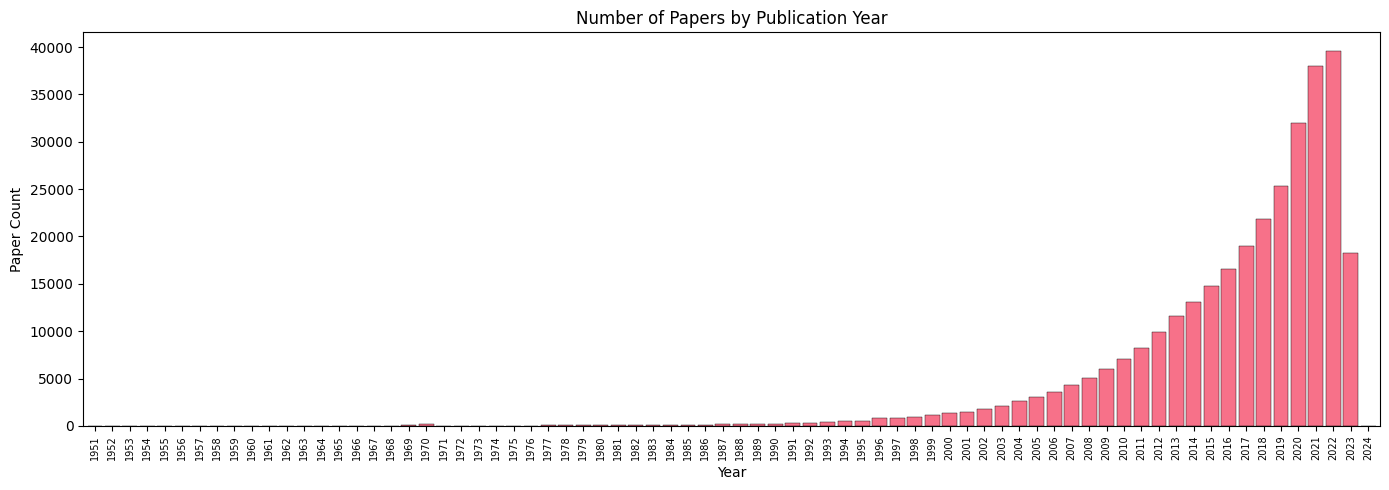

Year range: 1951 – 2024
Median year: 2018
Papers with missing year: 0


In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
year_counts = papers_df['published_year'].dropna().astype(int)
year_counts = year_counts[(year_counts >= 1950) & (year_counts <= 2025)]
year_counts.value_counts().sort_index().plot(kind='bar', ax=ax, width=0.85, edgecolor='black', linewidth=0.3)
ax.set_title("Number of Papers by Publication Year")
ax.set_xlabel("Year")
ax.set_ylabel("Paper Count")
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(f"Year range: {year_counts.min()} – {year_counts.max()}")
print(f"Median year: {int(year_counts.median())}")
print(f"Papers with missing year: {papers_df['published_year'].isna().sum():,}")